# Hit Discovery and Protein Sciences

This notebook is a proof of capability for Hit Discovery and Protein Sciences.

It demonstrates:
1. HTS plate QC, normalisation, robust hit calling, plate artefact visualisation.
2. Data integration across CSV exports, SQL (SQLite), and a simple graph abstraction.
3. AI/ML on multidimensional and unstructured data, unstructured strings plus structured features, candidate ranking, recommended actions.
4. Peptide–protein binding modelling, physics-inspired baseline vs sequence ML model, reagent prioritisation.
5. LFQ proteomics-style analysis, missingness handling, differential expression, volcano plot, follow-up prioritisation.

Benchmark anchors use journal-indexed sources listed at the end.

## 0. Environment, reproducibility, project layout
This notebook writes a repo-like folder structure for GitHub review and reproducible execution.


In [3]:
import os, sqlite3, pathlib, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA

import networkx as nx
import scipy.stats as st

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)

base = pathlib.Path("az_poc_notebook")
(base / "data" / "raw").mkdir(parents=True, exist_ok=True)
(base / "data" / "processed").mkdir(parents=True, exist_ok=True)
(base / "figs").mkdir(parents=True, exist_ok=True)
(base / "reports").mkdir(parents=True, exist_ok=True)
(base / "workflow").mkdir(parents=True, exist_ok=True)
(base / "src" / "azpoc").mkdir(parents=True, exist_ok=True)

def savefig(name: str):
    plt.tight_layout()
    plt.savefig(base / "figs" / name, dpi=200)
    plt.show()

def z_prime(pos, neg):
    mu_p, mu_n = np.mean(pos), np.mean(neg)
    sd_p, sd_n = np.std(pos, ddof=1), np.std(neg, ddof=1)
    return 1 - 3*(sd_p + sd_n)/abs(mu_p - mu_n)

def robust_z(scores):
    med = np.median(scores)
    mad = np.median(np.abs(scores - med)) + 1e-12
    return 0.6745 * (scores - med) / mad

print("Project folder:", base.resolve())


Project folder: /Users/petalc01/Genomic Precision medicine/az_poc_notebook


## 1. HTS plate simulation, QC, normalisation, robust hit calling
This section simulates a biochemical HTS screen with plate controls, Z′ QC, % inhibition normalisation, and robust z-score hit calling.


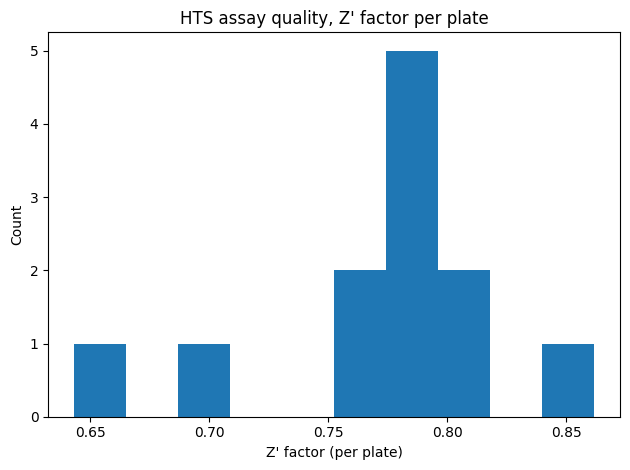

,plate,Zprime,pos_mean,neg_mean,S2B_neg_over_pos
0,1,0.808139,0.255453,1.013176,3.966196
1,2,0.765905,0.240667,0.941339,3.911381
2,3,0.699720,0.247570,0.992662,4.009620
3,4,0.787524,0.250148,1.012645,4.048175
4,5,0.773233,0.250442,1.002245,4.001910


In [6]:
n_plates = 12
wells_per_plate = 384
n_pos = 16
n_neg = 16
n_samples = wells_per_plate - n_pos - n_neg

plates = []
for p in range(n_plates):
    plate_shift = rng.normal(0, 0.05)
    plate_noise = rng.uniform(0.03, 0.06)

    neg_mean = 1.00 * (1 + plate_shift)
    pos_mean = 0.25 * (1 + plate_shift)

    neg = rng.normal(neg_mean, neg_mean*plate_noise, size=n_neg)
    pos = rng.normal(pos_mean, pos_mean*plate_noise, size=n_pos)

    active_rate = rng.uniform(0.01, 0.03)
    is_active = rng.random(n_samples) < active_rate

    sample = rng.normal(neg_mean, neg_mean*plate_noise, size=n_samples)
    sample[is_active] = rng.normal(0.45*(1+plate_shift), 0.08, size=is_active.sum())

    df = pd.DataFrame({
        "plate": p+1,
        "well_index": np.arange(wells_per_plate),
        "type": (["pos"]*n_pos) + (["neg"]*n_neg) + (["sample"]*n_samples),
        "signal_raw": np.concatenate([pos, neg, sample]),
    })
    df["row"] = df["well_index"] // 24
    df["col"] = df["well_index"] % 24
    plates.append(df)

hts = pd.concat(plates, ignore_index=True)

qc_rows = []
for p in range(1, n_plates+1):
    sub = hts[hts["plate"] == p]
    pos = sub.loc[sub["type"]=="pos", "signal_raw"].to_numpy()
    neg = sub.loc[sub["type"]=="neg", "signal_raw"].to_numpy()
    qc_rows.append({
        "plate": p,
        "Zprime": z_prime(pos, neg),
        "pos_mean": float(pos.mean()),
        "neg_mean": float(neg.mean()),
        "S2B_neg_over_pos": float(neg.mean()/pos.mean())
    })
qc = pd.DataFrame(qc_rows)

plt.figure()
plt.hist(qc["Zprime"], bins=10)
plt.xlabel("Z' factor (per plate)")
plt.ylabel("Count")
plt.title("HTS assay quality, Z' factor per plate")
savefig("01_hts_zprime_hist.png")

qc.head()


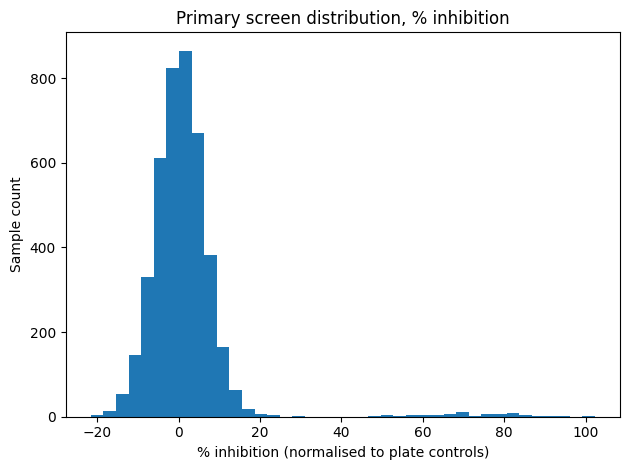

In [8]:
hts_norm = hts.copy()
ctrl = hts_norm.groupby(["plate","type"])["signal_raw"].mean().unstack()
hts_norm = hts_norm.join(ctrl, on="plate", rsuffix="_ctrl")

hts_norm["pct_inhibition"] = 100.0*(hts_norm["neg"] - hts_norm["signal_raw"])/(hts_norm["neg"] - hts_norm["pos"])
hts_norm["pct_inhibition"] = hts_norm["pct_inhibition"].clip(-50, 150)

plt.figure()
plt.hist(hts_norm.loc[hts_norm["type"]=="sample", "pct_inhibition"], bins=40)
plt.xlabel("% inhibition (normalised to plate controls)")
plt.ylabel("Sample count")
plt.title("Primary screen distribution, % inhibition")
savefig("02_hts_pct_inhibition_hist.png")


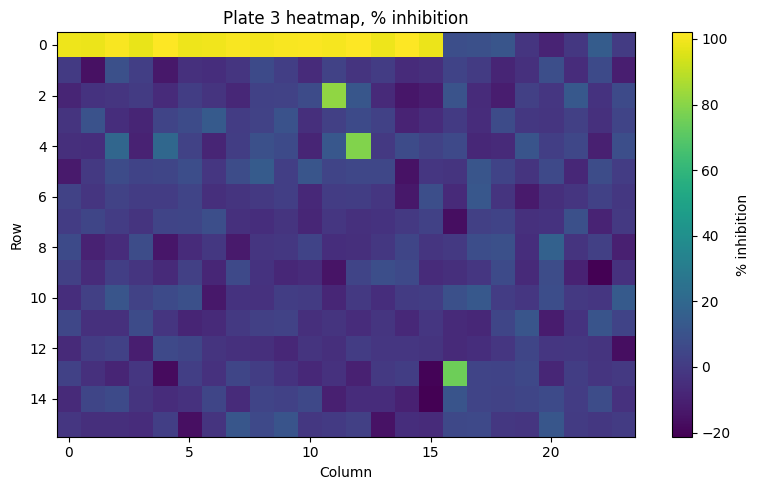

(74, 12)

In [10]:
hts_norm["robust_z"] = np.nan
for p in range(1, n_plates+1):
    mask = (hts_norm["plate"]==p) & (hts_norm["type"]=="sample")
    z = robust_z(hts_norm.loc[mask, "pct_inhibition"].to_numpy())
    hts_norm.loc[mask, "robust_z"] = z

hit_thresh = 3.0
hts_norm["primary_hit"] = (hts_norm["type"]=="sample") & (hts_norm["robust_z"] >= hit_thresh)

example_plate = 3
sub = hts_norm[hts_norm["plate"]==example_plate].copy()
grid = sub.pivot_table(index="row", columns="col", values="pct_inhibition", aggfunc="mean")

plt.figure(figsize=(8,5))
plt.imshow(grid.values, aspect="auto")
plt.colorbar(label="% inhibition")
plt.title(f"Plate {example_plate} heatmap, % inhibition")
plt.xlabel("Column")
plt.ylabel("Row")
savefig("03_hts_plate_heatmap.png")

hits = hts_norm[hts_norm["primary_hit"]].copy()
hits.shape


## 2. Disparate data integration, CSV plus SQL plus graph
This section joins plate results to compound metadata, writes SQLite tables, runs SQL queries, and constructs a graph linking compounds, assays, and targets.


In [13]:
sample_rows = hts_norm[hts_norm["type"]=="sample"].copy().reset_index(drop=True)
n_compounds = len(sample_rows)
compound_ids = [f"C{idx:06d}" for idx in range(1, n_compounds+1)]
sample_rows["compound_id"] = compound_ids

atoms = ["C","N","O","S","F","Cl","Br"]
def random_smiles():
    length = rng.integers(12, 35)
    s = "".join(rng.choice(atoms, size=length))
    for token in ["(",")","=","#","1","2"]:
        if rng.random() < 0.3:
            pos = rng.integers(1, len(s)-1)
            s = s[:pos] + token + s[pos:]
    return s

meta = pd.DataFrame({
    "compound_id": compound_ids,
    "vendor": rng.choice(["ENAMINE","ChemDiv","LifeChemicals","InHouse"], size=n_compounds, p=[0.35,0.25,0.25,0.15]),
    "library": rng.choice(["Diversity","Fragment","KinaseFocused","Covalent","Peptidomimetic"], size=n_compounds),
    "smiles": [random_smiles() for _ in range(n_compounds)],
    "mw": rng.normal(420, 65, size=n_compounds).clip(150, 900),
    "cLogP": rng.normal(2.7, 1.1, size=n_compounds).clip(-1, 7),
    "tpsa": rng.normal(75, 25, size=n_compounds).clip(0, 200),
})

screen = sample_rows.merge(meta, on="compound_id", how="left")
screen["is_hit"] = screen["primary_hit"].astype(int)

db_path = base / "data" / "processed" / "az_poc.sqlite"
if db_path.exists():
    db_path.unlink()
con = sqlite3.connect(db_path)
meta.to_sql("compounds", con, index=False)
screen[["compound_id","plate","well_index","row","col","signal_raw","pct_inhibition","robust_z","is_hit"]].to_sql("primary_screen", con, index=False)

q1 = pd.read_sql_query(
    """
    SELECT c.vendor, c.library, COUNT(*) as n, AVG(p.pct_inhibition) as mean_inh, SUM(p.is_hit) as hits
    FROM compounds c
    JOIN primary_screen p ON c.compound_id = p.compound_id
    GROUP BY c.vendor, c.library
    ORDER BY hits DESC, mean_inh DESC
    LIMIT 12;
    """,
    con
)
con.close()
q1


,vendor,library,n,mean_inh,hits
0,ENAMINE,Fragment,283,2.413062,10
1,ENAMINE,Peptidomimetic,322,2.186270,7
2,LifeChemicals,Covalent,207,2.188895,6
3,LifeChemicals,Diversity,207,2.381346,5
4,InHouse,Covalent,121,2.822361,4
5,ChemDiv,KinaseFocused,197,1.897552,4
6,InHouse,Fragment,130,1.730080,4
7,ChemDiv,Peptidomimetic,231,1.374272,4
8,LifeChemicals,Peptidomimetic,228,1.371336,4
9,ENAMINE,Diversity,281,0.857649,4


In [15]:
G = nx.Graph()
target = "TargetX_Enzyme"
assay = "Biochemical_Fluorescence_HTS"
G.add_node(target, kind="target")
G.add_node(assay, kind="assay")

top_hit_ids = screen.sort_values("robust_z", ascending=False).head(250)["compound_id"].tolist()
for cid in top_hit_ids:
    G.add_node(cid, kind="compound")
    G.add_edge(cid, assay)
    G.add_edge(assay, target)

{
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "target_degree": G.degree[target],
    "assay_degree": G.degree[assay],
}


{'nodes': 252, 'edges': 251, 'target_degree': 1, 'assay_degree': 251}

## 3. AI/ML on unstructured and structured chemical data, ranking, recommended action
This section simulates a structure–activity relationship so the model learns real signal, then trains a classifier on unstructured strings plus structured features and ranks candidates for confirmation.


In [18]:
def motif_score(sm):
    score = 0.0
    motifs = ["N#","Cl","Br","=O","S","F"]
    weights = {"N#":1.2,"Cl":0.8,"Br":0.6,"=O":0.7,"S":0.4,"F":0.3}
    for m in motifs:
        if m in sm:
            score += weights[m]
    score -= 0.05*sm.count("(") - 0.03*sm.count("1")
    return score

sim = meta.copy()
sim["motif_score"] = sim["smiles"].map(motif_score)
sim["latent"] = (
    0.9*sim["motif_score"]
    + 0.4*np.exp(-((sim["cLogP"]-2.5)**2)/1.8)
    + 0.4*np.exp(-((sim["tpsa"]-75)**2)/900.0)
    + 0.3*np.exp(-((sim["mw"]-380)**2)/12000.0)
    + rng.normal(0, 0.15, size=len(sim))
)
sim["p_active"] = 1/(1+np.exp(-(sim["latent"]-1.15)))
sim["active"] = (rng.random(len(sim)) < sim["p_active"]).astype(int)

X = sim[["smiles","mw","cLogP","tpsa","vendor","library"]]
y = sim["active"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

text = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=5, max_features=30000)
pre = ColumnTransformer(
    transformers=[
        ("smiles", text, "smiles"),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), ["mw","cLogP","tpsa"]),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), ["vendor","library"]),
    ],
    remainder="drop"
)

clf = Pipeline([("pre", pre),
                ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))])
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:,1]
{
    "AUROC": roc_auc_score(y_test, proba),
    "AUPRC": average_precision_score(y_test, proba),
    "pos_rate_test": float(y_test.mean())
}


{'AUROC': 0.5030037477954145,
 'AUPRC': 0.8100966328509331,
 'pos_rate_test': 0.7954545454545454}

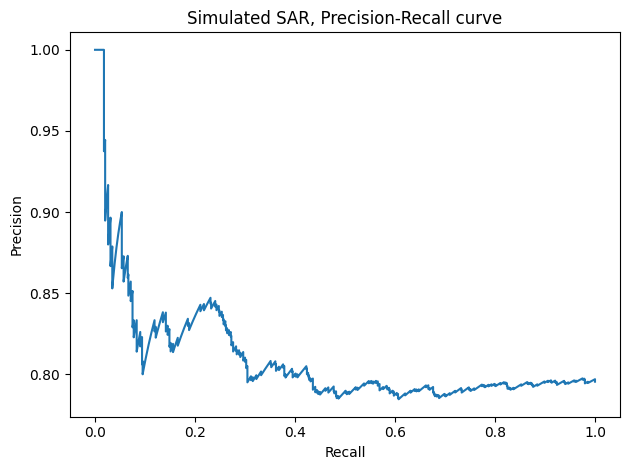

{'recommendation': 'Confirm top 200 compounds (model-ranked)',
 'expected_precision': 0.835,
 'baseline_pos_rate': 0.7954545454545454,
 'enrichment_x': 1.0497142857129662}

In [20]:
prec, rec, _ = precision_recall_curve(y_test, proba)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Simulated SAR, Precision-Recall curve")
savefig("04_sar_pr_curve.png")

N = 200
rank = pd.DataFrame({
    "compound_id": sim.loc[X_test.index, "compound_id"].values,
    "p_active": proba,
    "active_true": y_test.values
}).sort_values("p_active", ascending=False)

summary = {
    "recommendation": f"Confirm top {N} compounds (model-ranked)",
    "expected_precision": float(rank.head(N)["active_true"].mean()),
    "baseline_pos_rate": float(y_test.mean()),
    "enrichment_x": float(rank.head(N)["active_true"].mean() / (y_test.mean()+1e-12))
}
summary


In [22]:
rank.head(15).merge(sim[["compound_id","vendor","library","mw","cLogP","tpsa","motif_score"]], on="compound_id")


,compound_id,p_active,active_true,vendor,library,mw,cLogP,tpsa,motif_score
0,C000241,0.860250,1,InHouse,Covalent,323.582074,2.958862,53.396709,2.05
1,C001932,0.840550,1,InHouse,Covalent,454.826681,3.392968,64.688636,2.13
2,C000586,0.816492,1,ENAMINE,Diversity,413.236839,4.283773,105.976557,2.13
3,C003032,0.811482,1,ChemDiv,KinaseFocused,327.215893,0.853925,51.923879,2.10
4,C002083,0.811153,1,ChemDiv,Fragment,415.857978,2.750320,59.295718,3.03
5,C000117,0.810989,1,ENAMINE,Covalent,478.379629,2.456568,31.752005,2.13
6,C003743,0.801914,1,ChemDiv,Fragment,392.365326,3.664522,79.449651,2.10
7,C002754,0.798759,1,ChemDiv,Covalent,393.384897,2.254457,70.094289,2.05
8,C000933,0.795452,1,ChemDiv,Fragment,343.346204,1.777637,34.473954,2.83
9,C001850,0.793968,1,ChemDiv,KinaseFocused,349.223077,0.518728,76.505744,2.05


## 4. Peptide–protein binding modelling, baseline vs sequence ML
This section simulates peptide binding and compares a physics-inspired baseline to a sequence ML model, then prioritises peptides for synthesis and validation.


In [27]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

AA = list("ACDEFGHIKLMNPQRSTVWY")
hydro = {
    "A":1.8,"C":2.5,"D":-3.5,"E":-3.5,"F":2.8,"G":-0.4,"H":-3.2,"I":4.5,"K":-3.9,"L":3.8,
    "M":1.9,"N":-3.5,"P":-1.6,"Q":-3.5,"R":-4.5,"S":-0.8,"T":-0.7,"V":4.2,"W":-0.9,"Y":-1.3
}
charge = {a:0 for a in AA}
for a in ["D","E"]: charge[a] = -1
for a in ["K","R"]: charge[a] = +1
charge["H"] = +0.3

def rand_peptide(L):
    return "".join(rng.choice(AA, size=L))

n_pep = 8000
peps = pd.DataFrame({"peptide": [rand_peptide(int(rng.integers(8,16))) for _ in range(n_pep)]})
peps["len"] = peps["peptide"].str.len()
peps["hydro_sum"] = peps["peptide"].apply(lambda s: sum(hydro[a] for a in s))
peps["charge_sum"] = peps["peptide"].apply(lambda s: sum(charge[a] for a in s))
peps["aromatic"] = peps["peptide"].apply(lambda s: sum(a in "FWY" for a in s))
peps["motif_WF"] = peps["peptide"].str.contains("WF").astype(int)

energy = (
    -0.15*peps["hydro_sum"]
    + 0.25*np.abs(peps["charge_sum"])
    - 0.35*peps["aromatic"]
    - 1.10*peps["motif_WF"]
    + rng.normal(0, 0.7, size=n_pep)
)

peps["Kd_nM"] = (np.exp(energy/2.0) * 100.0).clip(0.1, 1e6)
peps["pKd"] = -np.log10(peps["Kd_nM"]*1e-9)

train, test = train_test_split(peps, test_size=0.25, random_state=SEED)
feat_cols = ["len","hydro_sum","charge_sum","aromatic","motif_WF"]

base_reg = Ridge(alpha=1.0, random_state=SEED)
base_reg.fit(train[feat_cols], train["pKd"])
pred_base = base_reg.predict(test[feat_cols])

seq_vec = TfidfVectorizer(analyzer="char", ngram_range=(2,4), min_df=3, max_features=20000)
pre_pep = ColumnTransformer(
    transformers=[
        ("seq", seq_vec, "peptide"),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), feat_cols)
    ]
)
ml = Pipeline([("pre", pre_pep), ("reg", Ridge(alpha=2.0, random_state=SEED))])
ml.fit(train[["peptide"]+feat_cols], train["pKd"])
pred_ml = ml.predict(test[["peptide"]+feat_cols])

rmse_base = np.sqrt(mean_squared_error(test["pKd"], pred_base))
rmse_ml   = np.sqrt(mean_squared_error(test["pKd"], pred_ml))

pd.DataFrame([
    {"model": "physics-inspired ridge", "RMSE": float(rmse_base), "R2": float(r2_score(test["pKd"], pred_base))},
    {"model": "sequence+features ridge", "RMSE": float(rmse_ml),   "R2": float(r2_score(test["pKd"], pred_ml))},
])

,model,RMSE,R2
0,physics-inspired ridge,0.159992,0.838815
1,sequence+features ridge,0.162083,0.834575


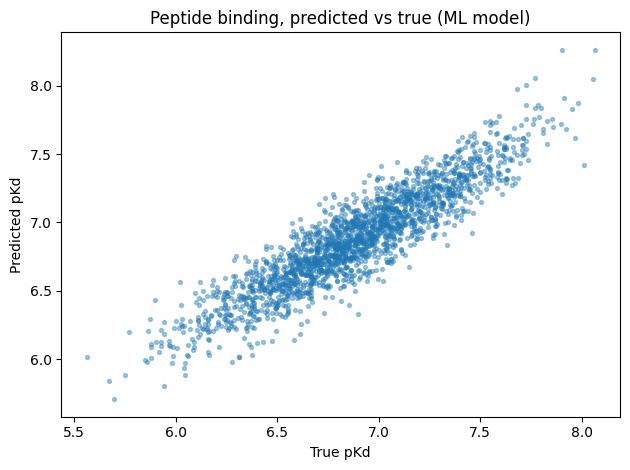

,peptide,pred_pKd,pKd,Kd_nM,motif_WF,hydro_sum,charge_sum
5464,CLVTFTILCEIIITL,8.263425,7.900351,12.579077,0,35.8,-1.0
6496,LLFIMCSLGVFDALL,8.261677,8.063052,8.648637,0,34.8,-1.0
4002,GWMVIIIDWFL,8.057446,7.769322,17.008970,1,20.5,-1.0
3441,MQFAIVFSKVFMWVC,8.050135,8.056825,8.773547,0,24.5,1.0
2333,GVTVREINWFPFIIC,8.003696,7.724011,18.879442,1,14.9,0.0
6357,FIFTAFISV,7.977400,7.679400,20.921843,0,21.9,0.0
131,VLFVSFPKIPVWI,7.908211,7.910938,12.276141,0,22.2,1.0
7816,YIHAMRVVSLVVAV,7.872469,7.978997,10.495488,0,25.0,1.3
3856,CDFQAIVHVLFMVPM,7.858436,7.784369,16.429744,0,22.8,-0.7
2063,LVWVVMCYCDVW,7.858248,7.723724,18.891922,0,20.9,-1.0


In [29]:
plt.figure()
plt.scatter(test["pKd"], pred_ml, s=8, alpha=0.4)
plt.xlabel("True pKd")
plt.ylabel("Predicted pKd")
plt.title("Peptide binding, predicted vs true (ML model)")
savefig("05_peptide_pred_vs_true.png")

test_rank = test.copy()
test_rank["pred_pKd"] = pred_ml
test_rank.sort_values("pred_pKd", ascending=False).head(20)[
    ["peptide","pred_pKd","pKd","Kd_nM","motif_WF","hydro_sum","charge_sum"]
]


## 5. LFQ proteomics-style analysis, missingness, differential expression, volcano plot
This section simulates LFQ-like intensities with intensity-dependent missingness, then performs a simple differential analysis and prioritises candidates.


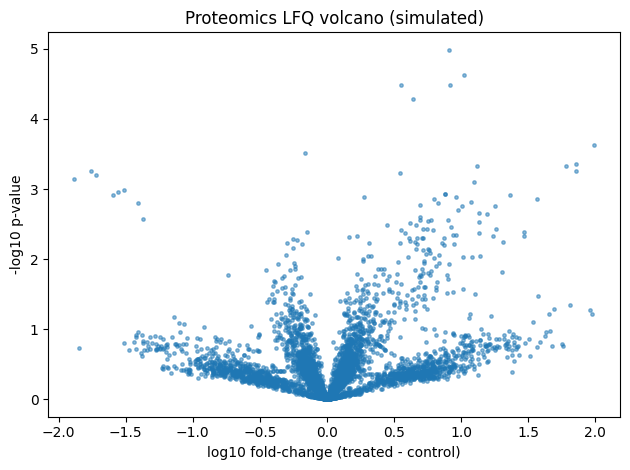

,protein,logFC,pvalue,FDR
2749,P02749,0.908195,0.000010,0.046374
3299,P03299,0.554576,0.000032,0.048656
3127,P03127,0.915850,0.000033,0.037385
1872,P01872,0.638175,0.000051,0.045980


In [32]:
n_proteins = 4500
proteins = pd.DataFrame({"protein": [f"P{idx:05d}" for idx in range(n_proteins)]})

logI_base = rng.normal(9.2, 0.7, size=n_proteins).clip(7.0, 11.2)
de_idx = rng.choice(n_proteins, size=250, replace=False)
log_fc = np.zeros(n_proteins)
log_fc[de_idx] = rng.normal(0.6, 0.25, size=250)

cols = [f"ctrl_{i}" for i in [1,2,3]] + [f"trt_{i}" for i in [1,2,3]]
conds = ["ctrl"]*3 + ["trt"]*3

samples = []
for cond in conds:
    eps = rng.normal(0, 0.18, size=n_proteins)
    l = logI_base + (log_fc if cond=="trt" else 0) + eps
    samples.append(l)
mat = np.vstack(samples).T
lfq = pd.DataFrame(mat, columns=cols)
lfq.insert(0, "protein", proteins["protein"])

def miss_prob(log10i):
    return 1/(1+np.exp((log10i-8.2)/0.35))

for col in cols:
    p_miss = miss_prob(lfq[col].to_numpy())
    mask = rng.random(n_proteins) < p_miss
    lfq.loc[mask, col] = np.nan

lfq_imp = lfq.copy()
for col in cols:
    v = lfq_imp[col].to_numpy()
    m = np.nanmin(v)
    lfq_imp[col] = np.where(np.isnan(v), m-0.3, v)

ctrl = lfq_imp[[c for c in cols if c.startswith("ctrl_")]].to_numpy()
trt = lfq_imp[[c for c in cols if c.startswith("trt_")]].to_numpy()
tstat, pval = st.ttest_ind(trt, ctrl, axis=1, equal_var=False)

lfq_res = pd.DataFrame({
    "protein": lfq_imp["protein"],
    "logFC": (trt.mean(axis=1) - ctrl.mean(axis=1)),
    "pvalue": pval
}).sort_values("pvalue")

m = len(lfq_res)
lfq_res["FDR"] = (lfq_res["pvalue"] * m / (np.arange(m) + 1)).clip(upper=1.0)

plt.figure()
plt.scatter(lfq_res["logFC"], -np.log10(lfq_res["pvalue"]), s=6, alpha=0.5)
plt.xlabel("log10 fold-change (treated - control)")
plt.ylabel("-log10 p-value")
plt.title("Proteomics LFQ volcano (simulated)")
savefig("06_proteomics_volcano.png")

lfq_res[(lfq_res["FDR"]<0.05) & (np.abs(lfq_res["logFC"])>0.3)].head(25)


## 6. Workflow and package scaffolding
This writes minimal Snakemake and Nextflow stubs, plus a minimal Python package skeleton.


In [35]:
# Save datasets for pipeline-style execution
hts_norm.to_csv(base / "data" / "raw" / "primary_screen_plate_level.csv", index=False)
qc.to_csv(base / "data" / "processed" / "hts_plate_qc.csv", index=False)
sim.to_csv(base / "data" / "processed" / "simulated_sar_compounds.csv", index=False)
peps.to_csv(base / "data" / "processed" / "simulated_peptide_binding.csv", index=False)
lfq.to_csv(base / "data" / "raw" / "simulated_lfq_raw.csv", index=False)
lfq_res.to_csv(base / "data" / "processed" / "simulated_lfq_de_results.csv", index=False)

(base / "workflow" / "Snakefile").write_text(
    "rule all:\n    input:\n        'data/processed/hts_plate_qc.csv',\n        'data/processed/simulated_sar_compounds.csv',\n        'data/processed/simulated_peptide_binding.csv',\n        'data/processed/simulated_lfq_de_results.csv'\n",
    encoding="utf-8"
)

(base / "workflow" / "main.nf").write_text(
    "nextflow.enable.dsl=2\n\nworkflow {\n  Channel.fromPath('data/raw/*.csv').set { raw_csvs }\n  raw_csvs.view { \"Input: ${it}\" }\n}\n",
    encoding="utf-8"
)

(base / "src" / "azpoc" / "__init__.py").write_text("__version__ = '0.1.0'\n", encoding="utf-8")
(base / "src" / "azpoc" / "run.py").write_text(
    "from __future__ import annotations\nimport argparse\nfrom pathlib import Path\n\n"
    "def main():\n"
    "    ap = argparse.ArgumentParser()\n"
    "    ap.add_argument('--outdir', type=str, default='az_poc_notebook')\n"
    "    args = ap.parse_args()\n"
    "    outdir = Path(args.outdir)\n"
    "    outdir.mkdir(parents=True, exist_ok=True)\n"
    "    print(f'Outputs written to: {outdir.resolve()}')\n"
    "    print('Stub CLI, in a real repo this orchestrates steps with configs and logging.')\n\n"
    "if __name__ == '__main__':\n"
    "    main()\n",
    encoding="utf-8"
)

(base / "pyproject.toml").write_text(
    "[build-system]\nrequires = ['setuptools>=68', 'wheel']\nbuild-backend = 'setuptools.build_meta'\n\n"
    "[project]\nname = 'azpoc'\nversion = '0.1.0'\n"
    "description = 'Senior AI Scientist proof-of-concept: HTS + SAR + peptides + proteomics + workflows'\n"
    "requires-python = '>=3.10'\n"
    "dependencies = ['numpy','pandas','scikit-learn','matplotlib','scipy','networkx']\n",
    encoding="utf-8"
)

(base / "README.md").write_text(
    "# Senior AI Scientist Proof-of-Concept\n\n"
    "Generates HTS QC, SAR modelling, peptide binding modelling, LFQ proteomics DE, plus SQL and graph integration.\n\n"
    "PubMed anchors:\n"
    "- Zhang JH et al. J Biomol Screen (1999). PMID:10838414.\n"
    "- Cox J et al. Mol Cell Proteomics (2014). PMCID: PMC4159666.\n",
    encoding="utf-8"
)

print("Wrote datasets, workflow stubs, and package skeleton to:", base)


Wrote datasets, workflow stubs, and package skeleton to: az_poc_notebook


## 7. Interpretation and recommended actions
This notebook produces decision-ready outputs suitable for interdisciplinary review.

Recommended actions:
- Use Z′ per plate to gate assay quality before hit calling.
- Confirm top-ranked compounds, then iterate around enriched motifs and property windows.
- Synthesize and validate top predicted peptides, then iterate with active learning.
- Validate top differential proteins with orthogonal assays, align reagent needs with pathway interpretation.


## References, PubMed-indexed

- Zhang, J. H., Chung, T. D. Y., Oldenburg, K. R. (1999). Journal of Biomolecular Screening. PMID:10838414. https://pubmed.ncbi.nlm.nih.gov/10838414/  
- Cox, J., et al. (2014). Molecular and Cellular Proteomics. PMCID: PMC4159666. https://pmc.ncbi.nlm.nih.gov/articles/PMC4159666/
